# Learning to stabilize a linear system with Robustness

We follow the examples in `example/control/Part_1_stabilize_linear_system` to demonstrate how to learn a robust stabilizing controller for a double integrator system using [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) and introduce a Lipschitz estimation method [EClipsE](https://proceedings.neurips.cc/paper_files/paper/2024/hash/1419d8554191a65ea4f2d8e1057973e4-Abstract-Conference.html) to charaterize the robustness of the learned controller. 
This notebook trains 3 controllers: (i) standard DPC; (ii) policy-Jacobian regularized; (iii) closed-loop-Jacobian regularized.

**Differentiable Predictive Control method**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In DPC, we construct a differentiable closed-loop system composed of neural control policy and system dynamics model that is to be optimized using parametric control objectives as intrinsic reward signals evaluated over a sampled distribution of the problem parameters.

<img src="./figs/DPC_simple_method.png" width="600">  

In this notebook, the closed-loop dynamics we optimize over are
$$
x_{k+1} = Ax_k + Bu_k, \qquad u_k = \pi_\theta(x_k),
$$
where $\pi_\theta$ is the learned neural controller for the double integrator system.


**Training Schedule**:  
To keep training efficient, we adapt **curriculum learning** schedule on the regularization: we first train a controller without Jacobian regularization (controller (i)) until it converges to a stabilizing solution, then we **warm-start** from that controller and proceed with further training with Jacobian regularization (policy-Jacobian regularized controller (ii), or closed-loop-Jacobian Regularized controller (iii)) to finetune. This avoids paying the full cost of the Jacobian penalty from the beginning and typically improves training stability.


**ECLipsE**:  
The Lipschitz constant plays a crucial role in certifying the robustness of neural networks to input perturbations. ***eclipse-nn*** package provides strict, accurate, efficient, and scalable $\ell_2$-norm Lipschitz estimates on FNN. One can check examples/robustness_with_Lipschitz_estimator/tutorial_Lipschitz_estimator.ipynb for the demonstration.

## NeuroMANCER , eclipse-nn and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [ ]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [ ]:
!pip install eclipse-nn

In [1]:
import torch
from torch import func
import copy
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.plot import pltCL, pltPhase

import warnings
warnings.filterwarnings("ignore")

In [2]:
from eclipse_nn.LipConstEstimator import LipConstEstimator

In [3]:
import random
import numpy as np

# Set random seeds
# Python built-in random
random.seed(42)
# NumPy
np.random.seed(42)
# PyTorch (CPU and GPU)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42) 

# Node and System classes

The Node class is a simple wrapper for any callable pytorch function or nn.Module which provides names for the inputs and outputs to be used in composition of a potentially cyclic computational graph.  

In this notebook, the dynamics Node is fixed and defined here, while the neural control policy Node(s) are defined later in the optimization section since the curriculum learning schedule warm-starts the regularized controllers from the baseline controller.



In [4]:
# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# Training dataset generation

For a training dataset we randomly sample points away from the origin of the 2D space the system operates in. 

In [5]:
# Training dataset generation
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  # Split conditions into train and dev
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')
train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                           collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                         collate_fn=dev_data.collate_fn, shuffle=False)

# Optimization problem with a system rollout of 2 time steps

We train a neural feedback controller for the double integrator:
$$
u_k = \pi_\theta(x_k), \qquad x_{k+1} = Ax_k + Bu_k.
$$
Training optimizes a rollout loss over a short horizon ($T=2$ time steps).

### 1) Standard DPC loss
For a rollout $k=0,\dots,T-1$, we penalize control effort by a scalar $Q_u$ and regulate the state to the origin with penalty weighted by $Q_x$:
$$
\mathcal{L}_{\mathrm{dpc}}
= \sum_{k=0}^{T-1} \Big( Q_u \|u_k\|_2^2 + Q_x \|x_k\|_2^2 \Big).
$$

### 2) Policy-Jacobian regularization
The policy Jacobian is
$$
J_\pi(x) = \frac{\partial \pi_\theta}{\partial x}(x).
$$
We add a robustness-promoting penalty
$$
\mathcal{L}^{\pi}_{\mathrm{rob}}
= \sum_{k=0}^{T-1} \|J_\pi(x_k)\|_F^2.
$$
The resulting training objective is
$$
\min_\theta\;\; \mathcal{L}_{\mathrm{dpc}} + Q_{\mathrm{J}}^{\pi}\,\mathcal{L}^{\pi}_{\mathrm{rob}},
$$
where $ Q_{\mathrm{J}}^{\pi} \ge 0$ weights the Jacobian regularization.

### 3) Closed-loop Jacobian regularization
For $F(x,u)=Ax+Bu$, the closed-loop map is $x \mapsto Ax + B\pi_\theta(x)$, so the Jacobian of the closed-loop system is 
$$
J_{\mathrm{cl}}(x)
= \frac{\partial}{\partial x}\big(Ax + B\pi_\theta(x)\big)
= A + B\,J_\pi(x).
$$
We add the penalty
$$
\mathcal{L}^{\mathrm{cl}}_{\mathrm{rob}}
= \sum_{k=0}^{T-1} \|J_{\mathrm{cl}}(x_k)\|_F^2.
$$
The resulting training objective is
$$
\min_\theta\;\; \mathcal{L}_{\mathrm{dpc}} + Q_{\mathrm{J}}^{\mathrm{cl}}\,\mathcal{L}^{\mathrm{cl}}_{\mathrm{rob}},
$$
where $Q_{\mathrm{J}}^{\mathrm{cl}} \ge 0$ weights the closed-loop Jacobian regularization.

### Curriculum learning schedule
We use curriculum learning over the regularizer:
1) train the base policy with $\mathcal{L}_{\mathrm{dpc}}$;
2) copy the trained policy and fine-tune with $\mathcal{L}_{\mathrm{dpc}} + Q_{\mathrm{J}}^{\pi}\,\mathcal{L}^{\pi}_{\mathrm{rob}}$ (policy Jacobian) or $\mathcal{L}_{\mathrm{dpc}} + Q_{\mathrm{J}}^{\mathrm{cl}}\,\mathcal{L}^{\mathrm{cl}}_{\mathrm{rob}}$ (closed-loop Jacobian).


## Standard Training

In [6]:
# neural control policy
mlp = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy = Node(mlp, ['X'], ['U'], name='policy')

# closed loop system definition
cl_system = System([policy, double_integrator])
# cl_system.show()

In [7]:
# Define optimization problem
u = variable('U')
x = variable('X')
action_loss = 0.0001 * (u == 0.)^2  # control penalty
regulation_loss = 10. * (x == 0.)^2  # target position
loss = PenaltyLoss([action_loss, regulation_loss], [])
problem = Problem([cl_system], loss)
optimizer = torch.optim.AdamW(policy.parameters(), lr=0.001)

In [8]:
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=1000,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)

# Train model with prediction horizon of 2
cl_system.nsteps = 2
best_model = trainer.train()

epoch: 0  train_loss: 202.42628479003906
epoch: 1  train_loss: 201.84446716308594
epoch: 2  train_loss: 201.25
epoch: 3  train_loss: 200.6475067138672
epoch: 4  train_loss: 200.03172302246094
epoch: 5  train_loss: 199.40264892578125
epoch: 6  train_loss: 198.76254272460938
epoch: 7  train_loss: 198.11053466796875
epoch: 8  train_loss: 197.44590759277344
epoch: 9  train_loss: 196.77001953125
epoch: 10  train_loss: 196.0867156982422
epoch: 11  train_loss: 195.40872192382812
epoch: 12  train_loss: 194.7261962890625
epoch: 13  train_loss: 194.01625061035156
epoch: 14  train_loss: 193.2728271484375
epoch: 15  train_loss: 192.4952392578125
epoch: 16  train_loss: 191.68118286132812
epoch: 17  train_loss: 190.82876586914062
epoch: 18  train_loss: 189.9380645751953
epoch: 19  train_loss: 189.00718688964844
epoch: 20  train_loss: 188.03286743164062
epoch: 21  train_loss: 187.0134735107422
epoch: 22  train_loss: 185.9462890625
epoch: 23  train_loss: 184.82933044433594
epoch: 24  train_loss: 183.6

## Apply Curriculum Training and add regularization on the Jacobian of policy u=NN(x)
We warm-start from the standard trained policy and fine-tune with a Jacobian penalty on u=NN(x).


In [9]:
# reuse the trained NN
policy_reg = copy.deepcopy(policy)
model = policy_reg.callable

def jac_calculator(X):
    batch_jac = func.vmap(
        func.jacrev(lambda x_single: model(x_single.unsqueeze(0)).view(-1))
    )(X)  # [Batch, nu, nx]
    return torch.linalg.norm(batch_jac, ord='fro', dim=(-2, -1)).unsqueeze(-1)  # [Batch, 1]

jac_fro = Node(jac_calculator, ['X'], ['Jfro'], name='jac_fro')

# closed loop system definition (add the jac_fro node)
cl_system_reg = System([policy_reg, double_integrator, jac_fro])


In [10]:
# variables
u = variable('U')
x = variable('X')
j = variable('Jfro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_loss    = 0.1 * (j == 0.)^2 

loss_reg = PenaltyLoss([action_loss, regulation_loss,jac_loss], [])
problem_reg = Problem([cl_system_reg], loss_reg)

optimizer = torch.optim.AdamW(policy_reg.parameters(), lr=0.0003)

In [11]:
trainer_reg = Trainer(
    problem_reg,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg.nsteps = 2
best_model_reg = trainer_reg.train()

epoch: 0  train_loss: 40.61136245727539
epoch: 1  train_loss: 40.615692138671875
epoch: 2  train_loss: 40.6114387512207
epoch: 3  train_loss: 40.61095428466797
epoch: 4  train_loss: 40.61289596557617
epoch: 5  train_loss: 40.61194610595703
epoch: 6  train_loss: 40.60986328125
epoch: 7  train_loss: 40.609588623046875
epoch: 8  train_loss: 40.6099739074707
epoch: 9  train_loss: 40.60993576049805
epoch: 10  train_loss: 40.60935974121094
epoch: 11  train_loss: 40.60874557495117
epoch: 12  train_loss: 40.60865020751953
epoch: 13  train_loss: 40.609405517578125
epoch: 14  train_loss: 40.609317779541016
epoch: 15  train_loss: 40.60869216918945
epoch: 16  train_loss: 40.60802459716797
epoch: 17  train_loss: 40.607643127441406
epoch: 18  train_loss: 40.6075553894043
epoch: 19  train_loss: 40.60731506347656
epoch: 20  train_loss: 40.606929779052734
epoch: 21  train_loss: 40.60663986206055
epoch: 22  train_loss: 40.606685638427734
epoch: 23  train_loss: 40.60660934448242
epoch: 24  train_loss: 40

## Train with regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x))
We warm-start from the standard trained policy and fine-tune with a Jacobian penalty on the closed-loop map x -> f(x,NN(x)).


In [12]:
# reuse the trained NN
policy_reg_cl = copy.deepcopy(policy)
model_cl = policy_reg_cl.callable

def jac_cl_calculator(X):
    batch_j_pi = func.vmap(
        func.jacrev(lambda x_single: model_cl(x_single.unsqueeze(0)).view(-1))
    )(X)  # [Batch, nu, nx]

    A_ = A.to(device=X.device, dtype=X.dtype)
    B_ = B.to(device=X.device, dtype=X.dtype)

    J_cl = A_ + torch.matmul(B_, batch_j_pi)  # [Batch, nx, nx]
    return torch.linalg.norm(J_cl, ord='fro', dim=(-2, -1)).unsqueeze(-1)  # [Batch, 1]

jac_cl_node = Node(jac_cl_calculator, ['X'], ['Jcl_fro'], name='jac_cl')

# closed loop system definition (add the jac_cl_node)
cl_system_reg_cl = System([policy_reg_cl, double_integrator, jac_cl_node])


In [13]:
# variables
u = variable('U')
x = variable('X')
jcl = variable('Jcl_fro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_cl_loss    = 4 * (jcl == 0.)^2 

loss_reg_cl = PenaltyLoss([action_loss, regulation_loss,jac_cl_loss], [])
problem_reg_cl = Problem([cl_system_reg_cl], loss_reg_cl)


optimizer = torch.optim.AdamW(policy_reg_cl.parameters(), lr=0.0003)

trainer_reg_cl = Trainer(
    problem_reg_cl,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg_cl.nsteps = 2
best_model_reg_cl = trainer_reg_cl.train()

epoch: 0  train_loss: 42.548709869384766
epoch: 1  train_loss: 42.54574966430664
epoch: 2  train_loss: 42.544837951660156
epoch: 3  train_loss: 42.54610061645508
epoch: 4  train_loss: 42.54484176635742
epoch: 5  train_loss: 42.541996002197266
epoch: 6  train_loss: 42.538490295410156
epoch: 7  train_loss: 42.5348014831543
epoch: 8  train_loss: 42.53136444091797
epoch: 9  train_loss: 42.528099060058594
epoch: 10  train_loss: 42.528106689453125
epoch: 11  train_loss: 42.527530670166016
epoch: 12  train_loss: 42.52647018432617
epoch: 13  train_loss: 42.52668380737305
epoch: 14  train_loss: 42.525245666503906
epoch: 15  train_loss: 42.522457122802734
epoch: 16  train_loss: 42.51896286010742
epoch: 17  train_loss: 42.51704788208008
epoch: 18  train_loss: 42.51488494873047
epoch: 19  train_loss: 42.51297378540039
epoch: 20  train_loss: 42.51329803466797
epoch: 21  train_loss: 42.5130729675293
epoch: 22  train_loss: 42.51280212402344
epoch: 23  train_loss: 42.51290512084961
epoch: 24  train_lo

# Evaluate best model on a system rollout 
We evaluate all three controllers on a longer rollout horizon and compare state trajectories and control inputs.


## Standard Training

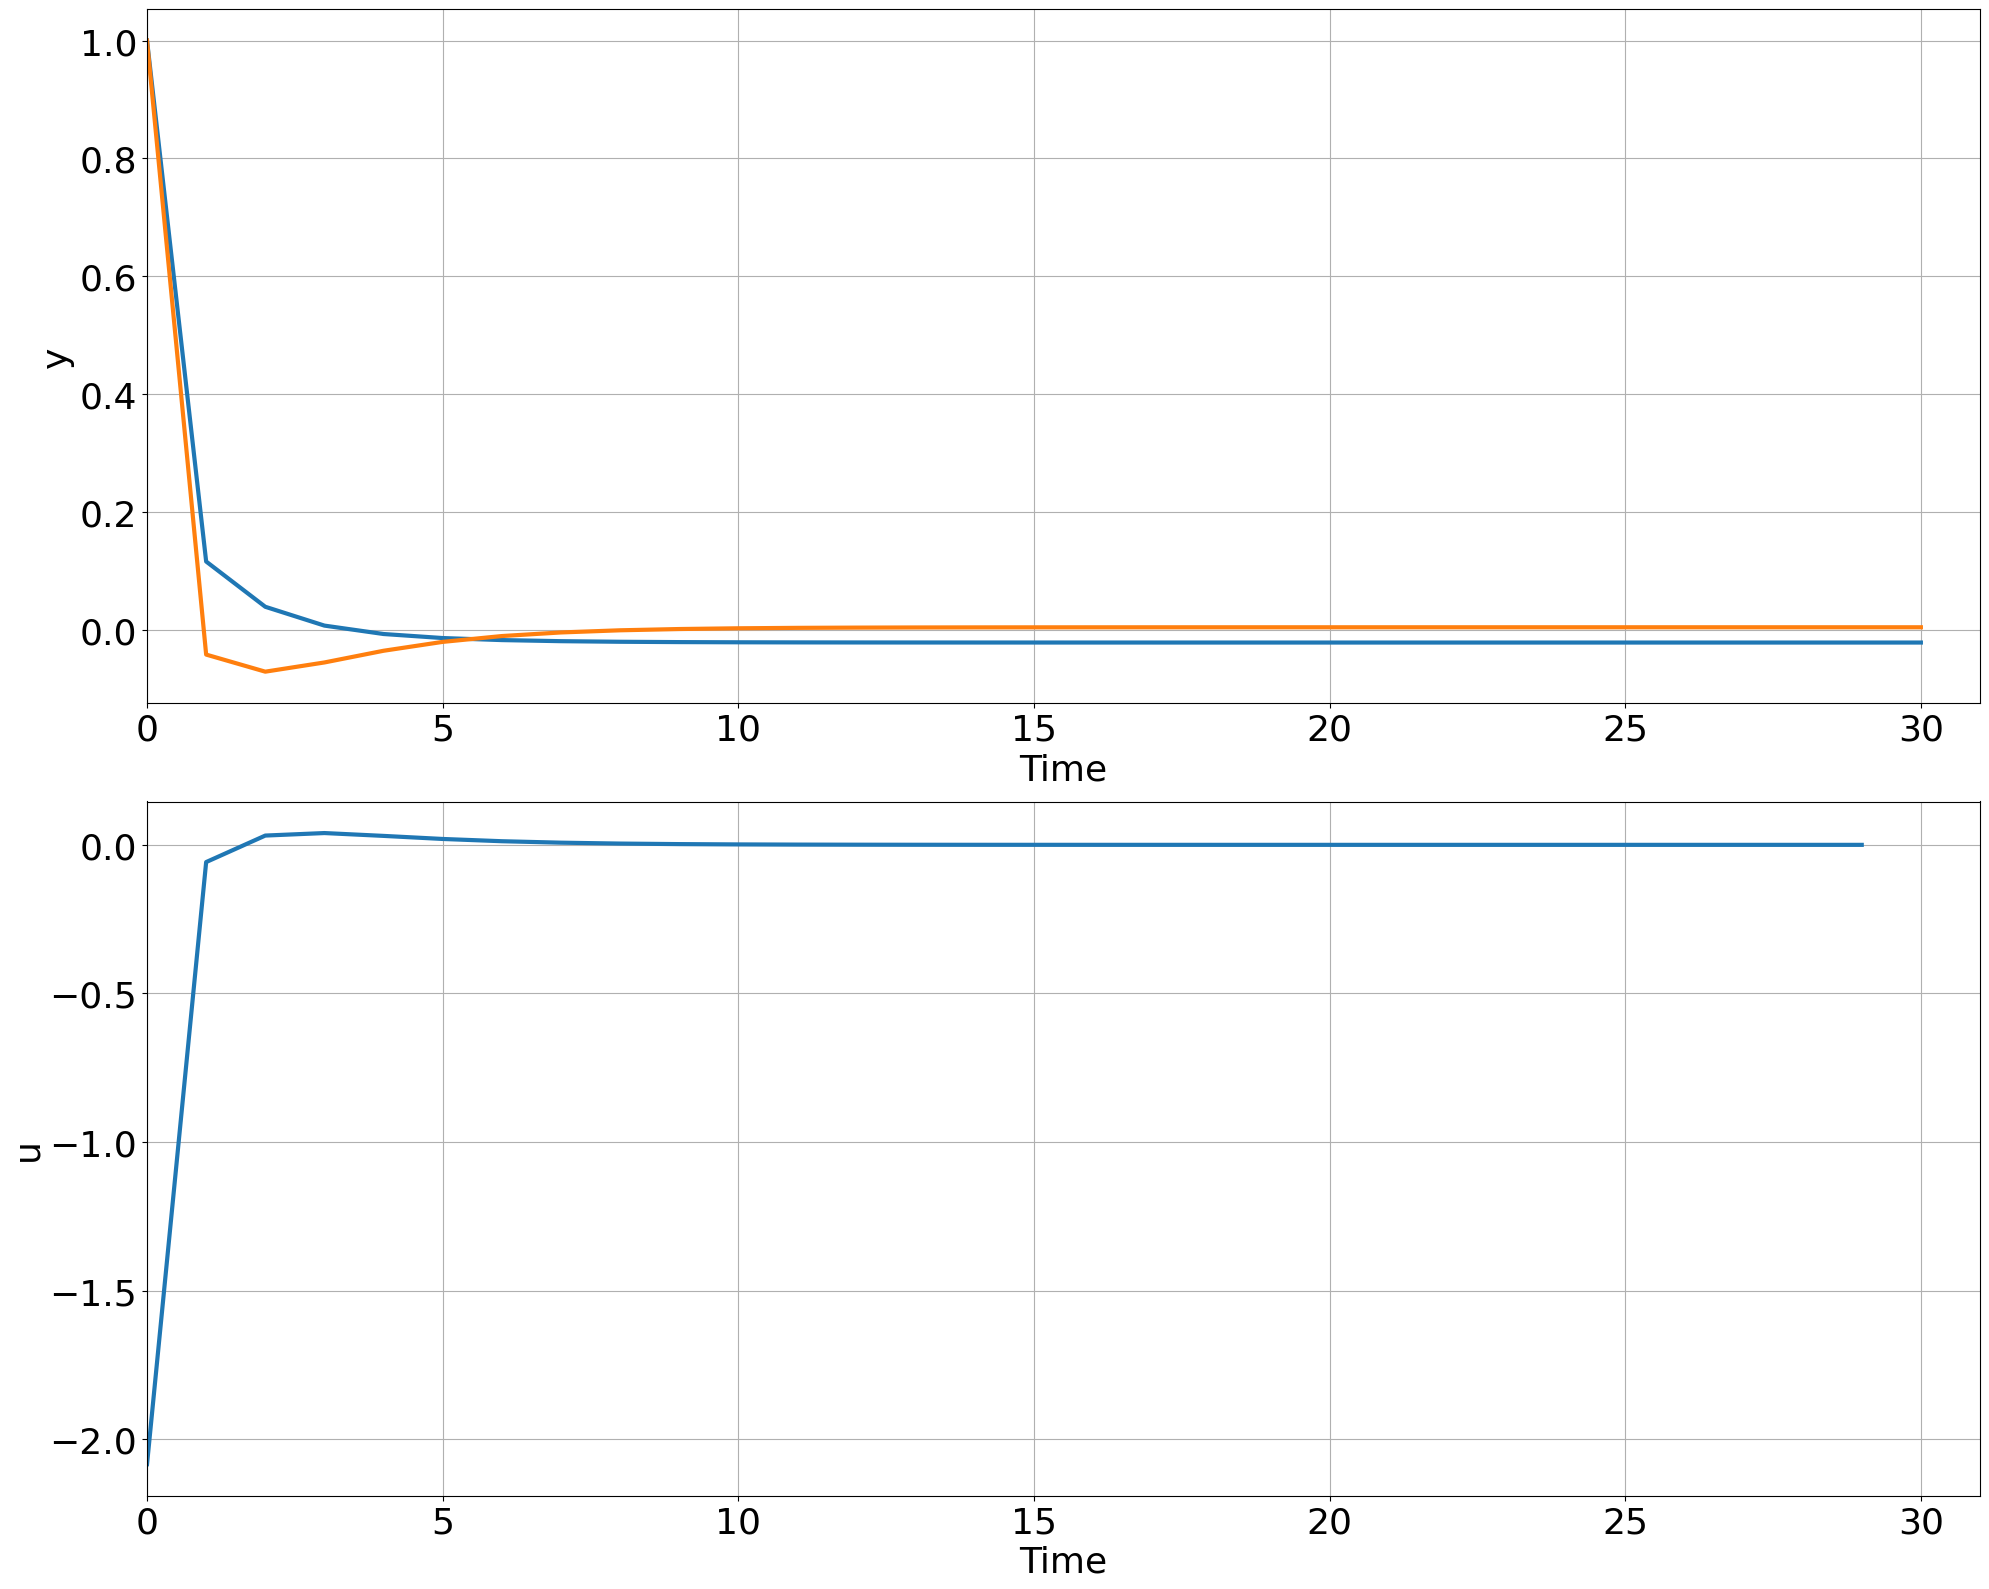

<Figure size 640x480 with 0 Axes>

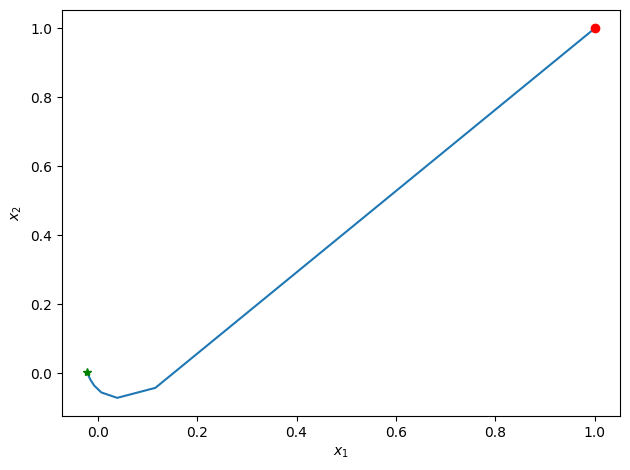

<Figure size 640x480 with 0 Axes>

In [14]:
# Test best model with prediction horizon of 30
problem.load_state_dict(best_model)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system.nsteps = nsteps
trajectories = cl_system(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of policy u=NN(x)

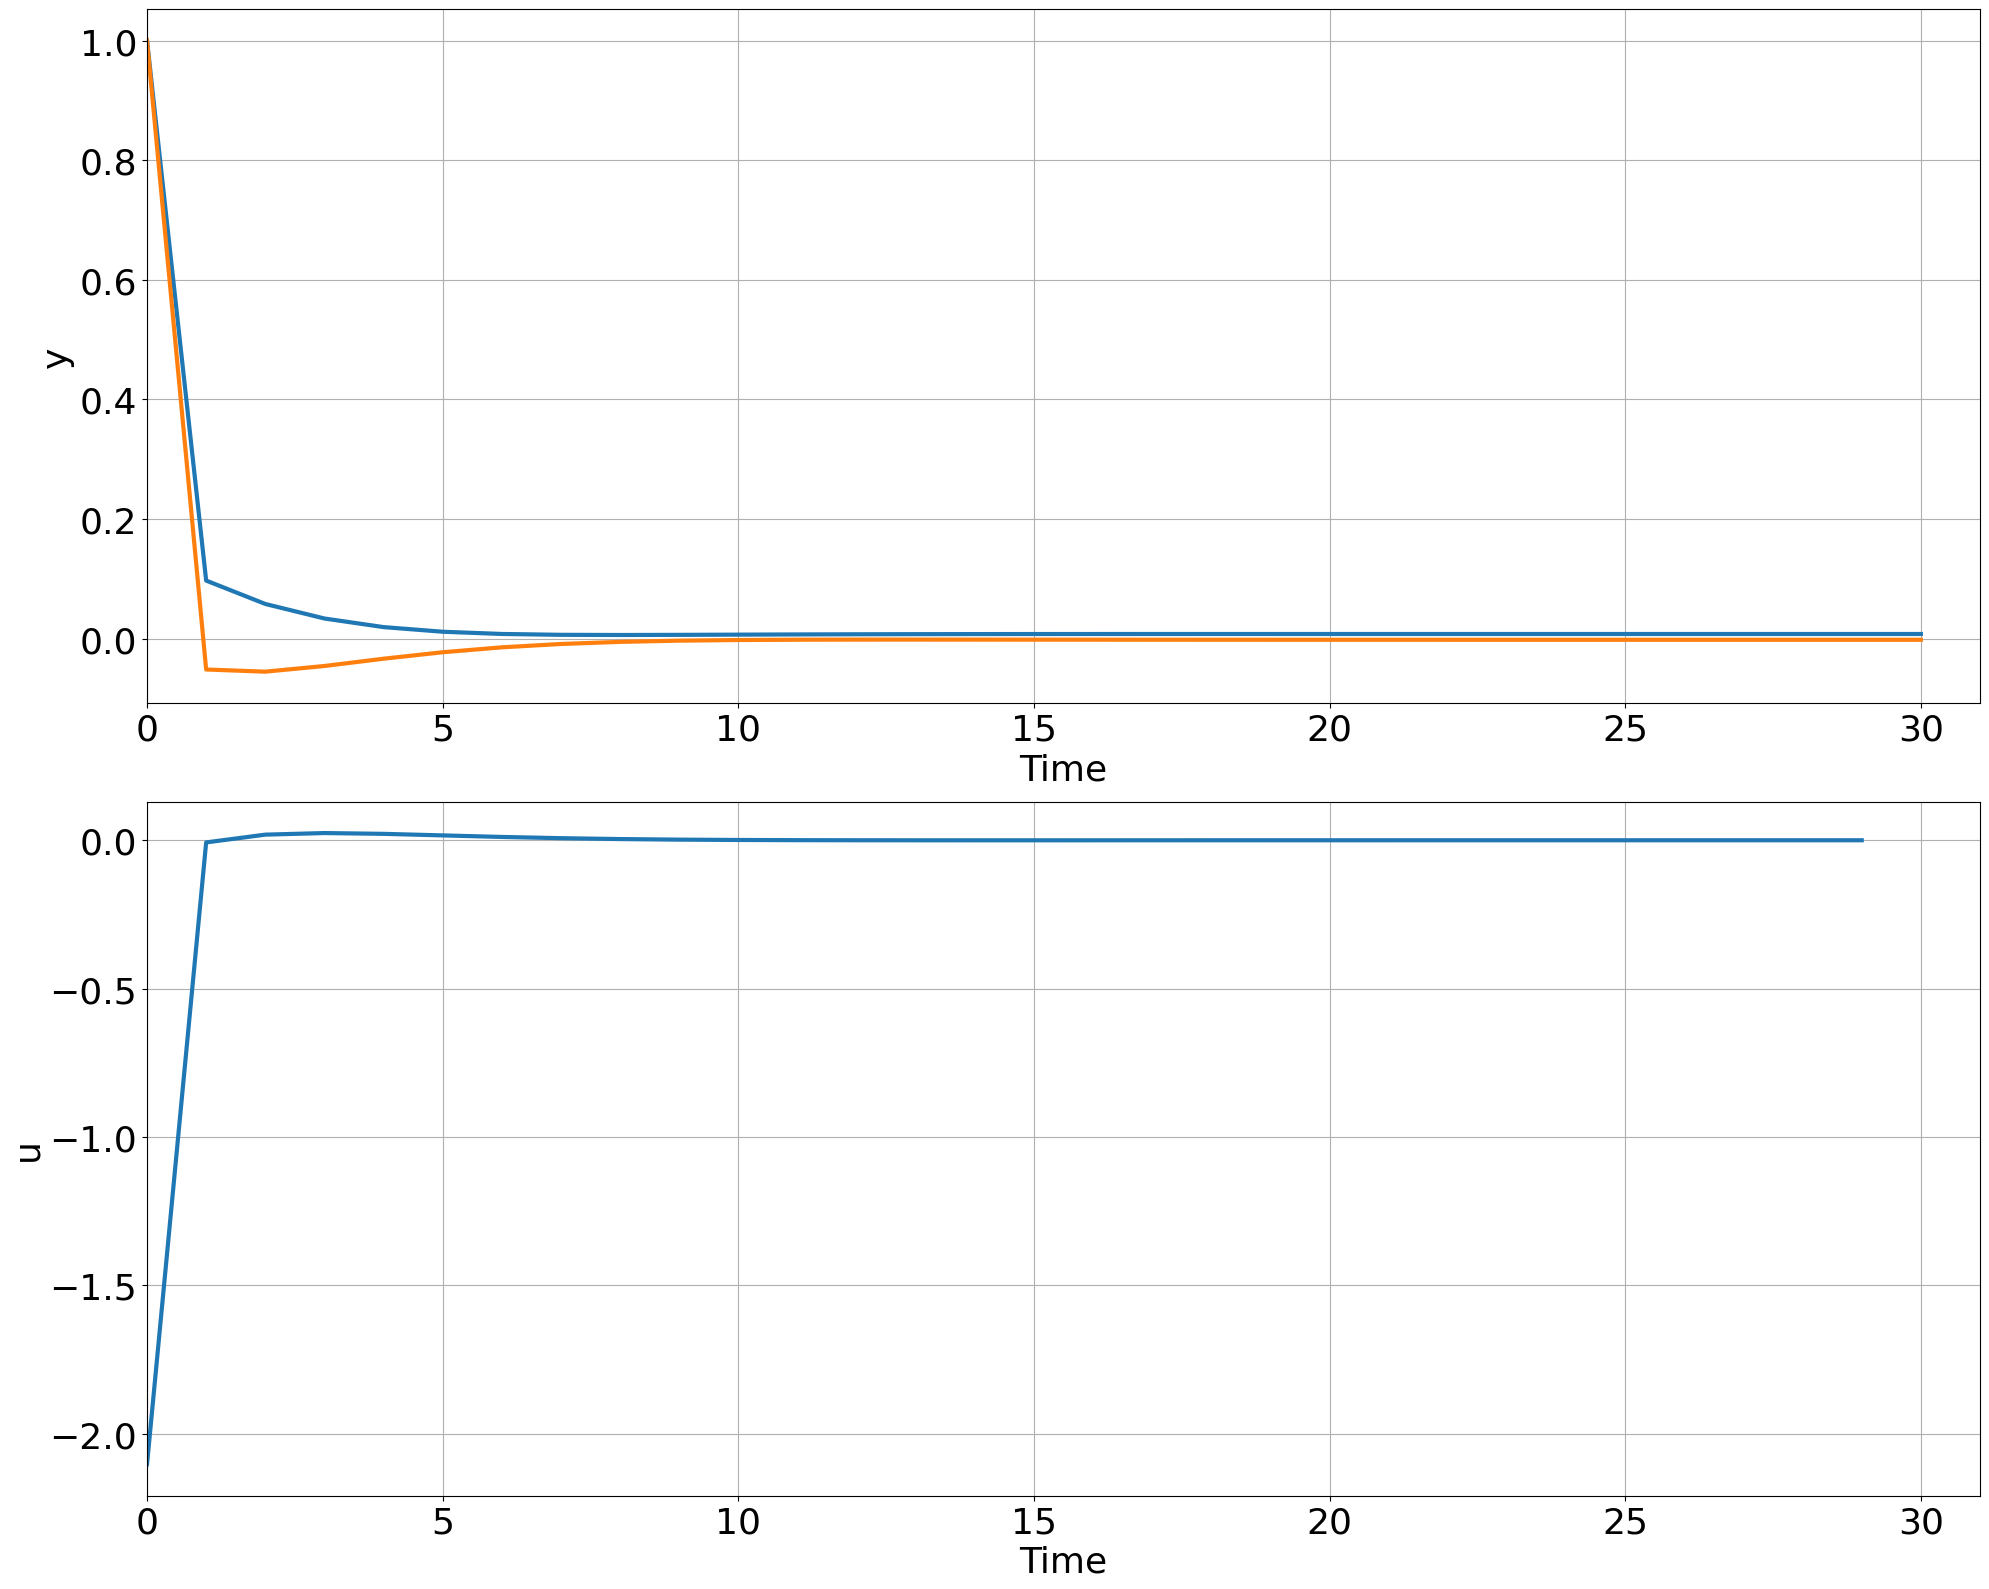

<Figure size 640x480 with 0 Axes>

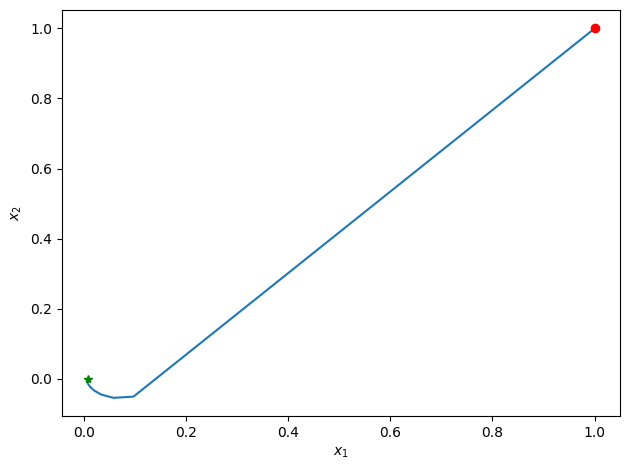

<Figure size 640x480 with 0 Axes>

In [15]:
# Test best model with prediction horizon of 50
problem_reg.load_state_dict(best_model_reg)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg.nsteps = nsteps
trajectories = cl_system_reg(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x)).

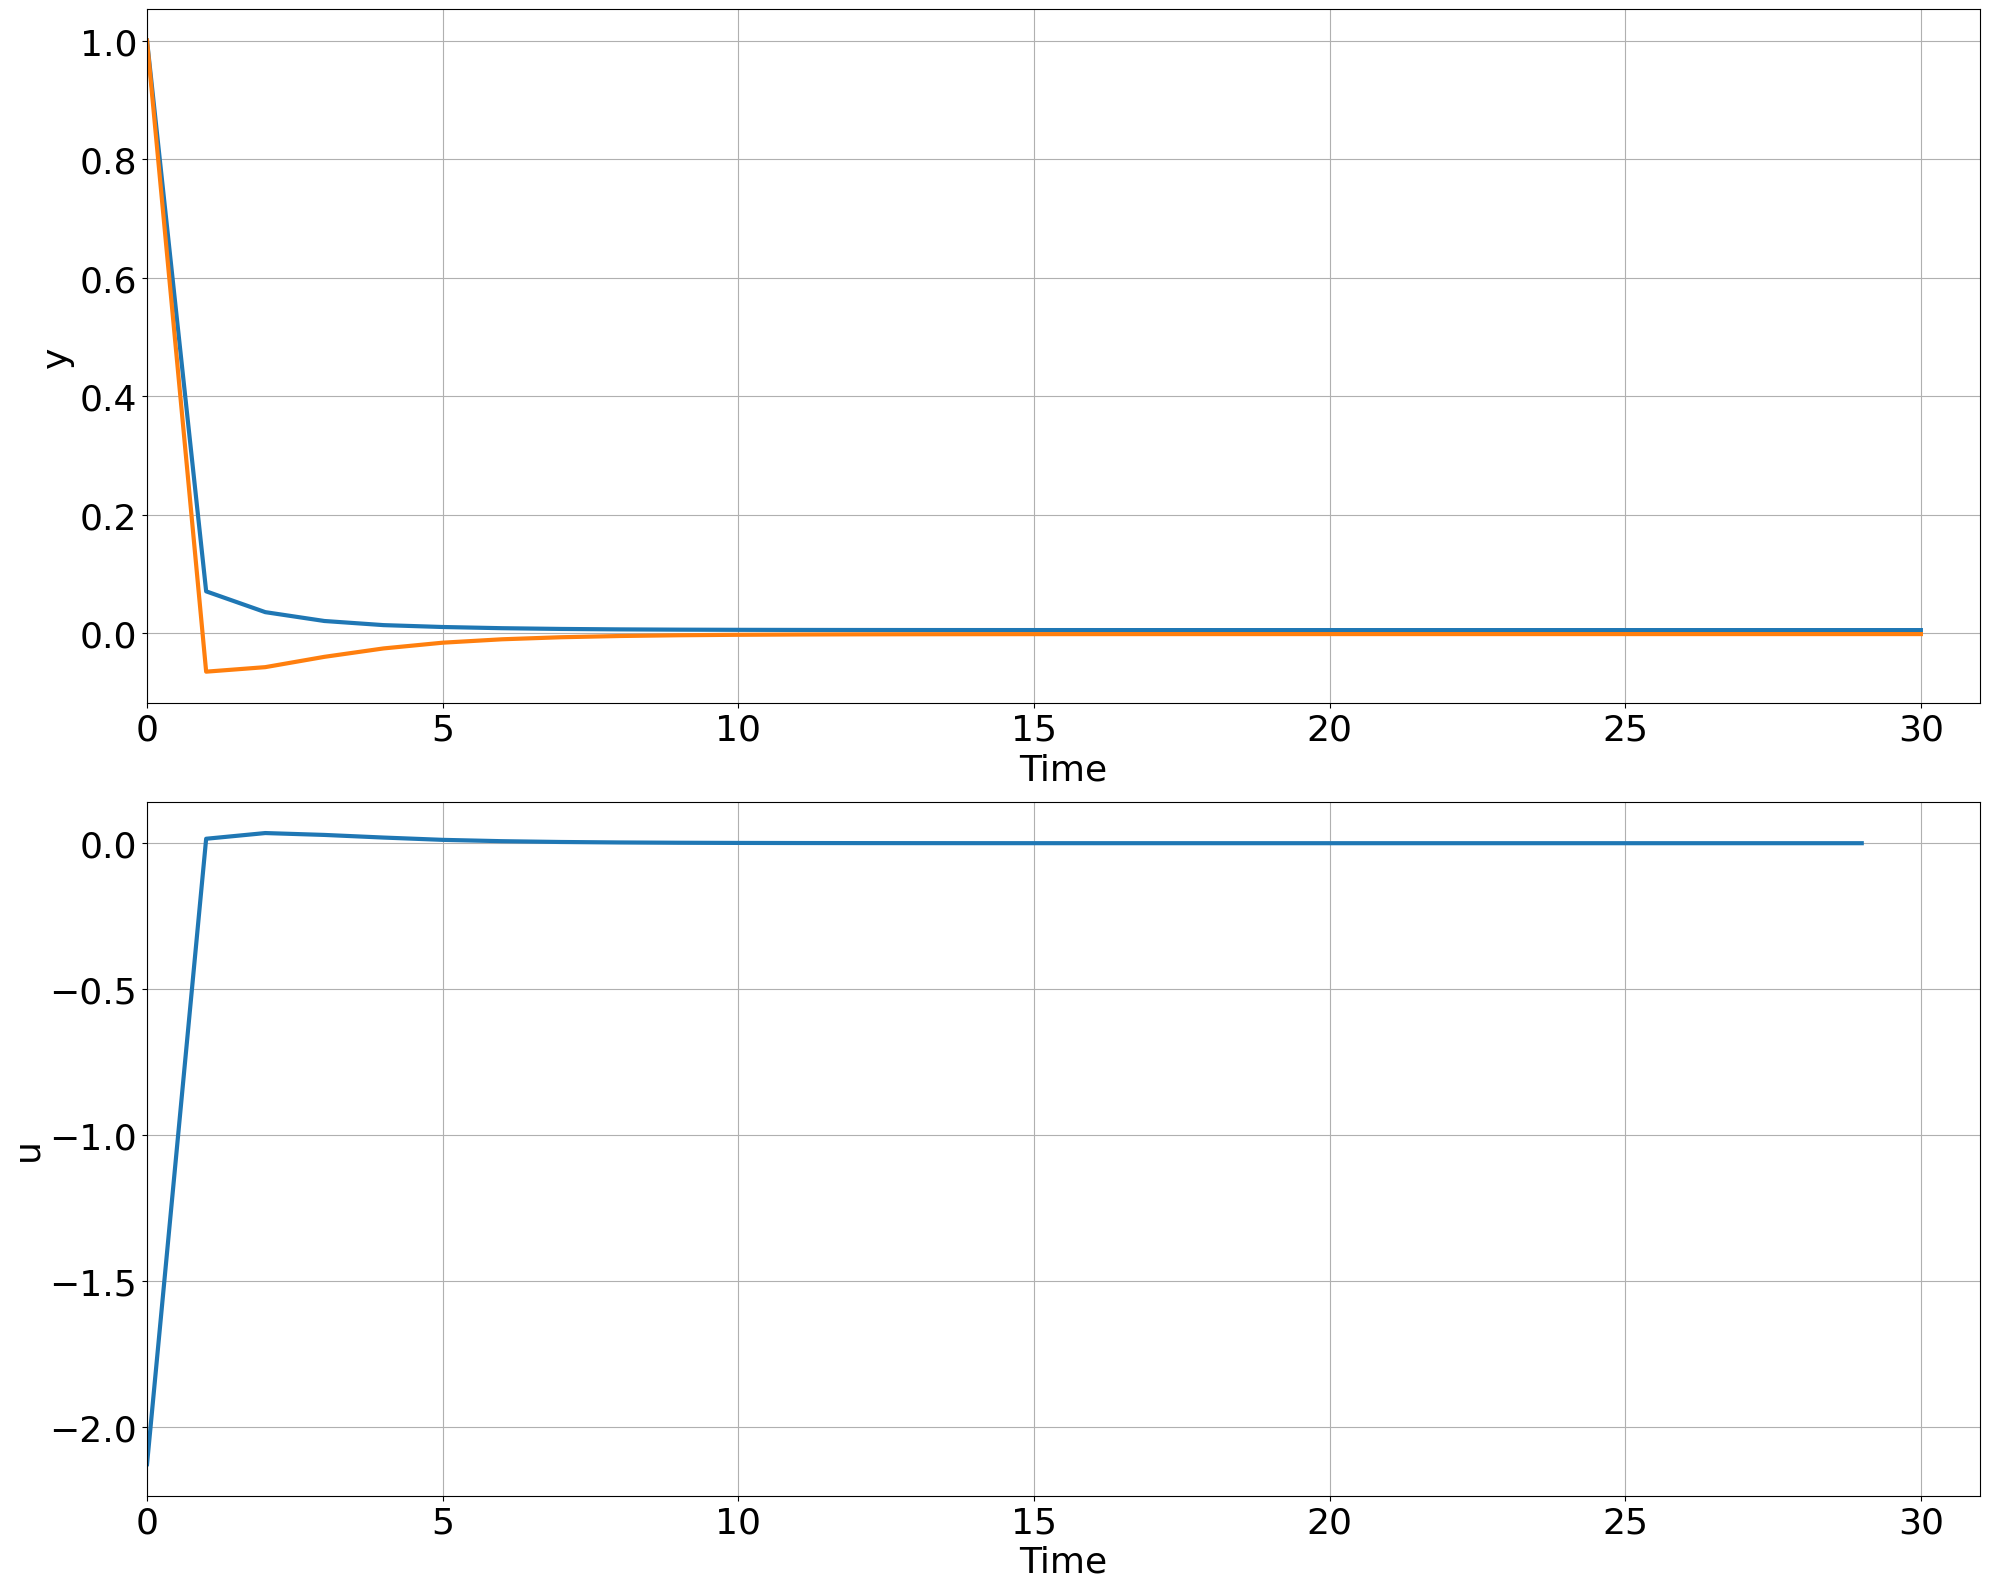

<Figure size 640x480 with 0 Axes>

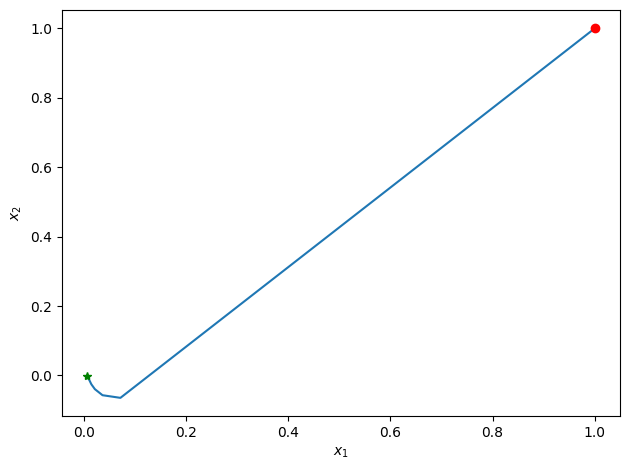

<Figure size 640x480 with 0 Axes>

In [16]:
# Test best model with prediction horizon of 50
problem_reg_cl.load_state_dict(best_model_reg_cl)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg_cl.nsteps = nsteps
trajectories = cl_system_reg_cl(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')


# Robustness Testing
Now we estimate the Lipschitz constant of all the three neural controllers u=NN(x).

In [17]:
import re

def extract_eclipse_tensors(model_dict, device='cpu'):
    """
    Extracts weights from a Neuromancer state_dict as a list of Double-Precision Tensors
    suitable for eclipse-nn input.
    
    Args:
        model_dict (dict): The state_dict from best_model (e.g., best_model_reg)
        device (str): 'cpu' or 'cuda'.
    
    Returns:
        weights (list of torch.Tensor): [W1, W2, ..., Wn] in float64
    """
    layer_weights = {}
    
    # Regex to capture layer index from keys like 'nodes.0...linear.0.weight'
    pattern = re.compile(r"linear\.(\d+)\.(weight)")
    
    for key, val in model_dict.items():
        match = pattern.search(key)
        if match:
            layer_idx = int(match.group(1))
            
            # CRITICAL FIX: Add .double() to match eclipse-nn's float64 requirement
            w_tensor = val.detach().clone().double().to(device)
            
            layer_weights[layer_idx] = w_tensor

    # Sort keys to ensure order: Layer 0 -> Layer 1 -> ...
    sorted_indices = sorted(layer_weights.keys())
    
    weights_list = [layer_weights[i] for i in sorted_indices]
    
    print(f"Extracted {len(weights_list)} weight matrices (float64).")
    return weights_list

In [18]:
Ws = extract_eclipse_tensors(best_model, device='cpu')
est = LipConstEstimator(weights=Ws)
lip = est.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from standard training is {lip}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller from standard training is 3.6568986851866


In [19]:
Ws_reg = extract_eclipse_tensors(best_model_reg, device='cpu')
est_reg = LipConstEstimator(weights=Ws_reg)
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is {lip_reg}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is 3.4275073357562857


In [20]:
Ws_reg_cl = extract_eclipse_tensors(best_model_reg_cl, device='cpu')
est_reg_cl = LipConstEstimator(weights=Ws_reg_cl)
lip_reg_cl = est_reg_cl.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of closed-loop system  is {lip_reg_cl}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller trained with regularization on the Jacobian of closed-loop system  is 3.22574002138319


## Observation
All three controllers stabilize the double integrator quickly on this rollout, with the state converging to the origin and the control input decaying to zero after the initial corrective action. The Lipschitz estimates of controllers trained with regularization on the Jacobian of the controller and the Jacobian of the closed-loop dynamics are smaller than the one from standard training, aligning with the enhanced smoothness in the control input mapping and reduced sensitivity of the resulting trajectories. Such enhanced smoothness is desirable for controller design. In addition, the controller trained with closed-loop Jacobian regularization tends to drive the state more directly toward the equilibrium, which is consistent with penalizing the local closed-loop gain: making $J_{\mathrm{cl}}$ small near the equilibrium promotes more contractive closed-loop behavior and reduces overshoot/oscillation around the equilibrium.